In [6]:
import sys
from pathlib import Path

# go from notebooks/ → project root
ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT))

print("ROOT added to path:", ROOT)

ROOT added to path: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization


In [ ]:
import matplotlib.pyplot as plt

def plot_attribution(attribution):
    plt.figure()
    plt.bar(attribution['channelGrouping'], attribution['revenue'])
    plt.xticks(rotation=45)
    plt.title("Revenue by Channel (Last Click Attribution)")
    plt.show()

📥 Loading: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/data/processed/clean.parquet
Shape: (50000, 7)
         fullVisitorId     visitId      visitStartTime channelGrouping  \
0  1131660440785968503  1472830385 2016-09-02 15:33:05  Organic Search   
1   377306020877927890  1472880147 2016-09-03 05:22:27  Organic Search   
2  3895546263509774583  1472865386 2016-09-03 01:16:26  Organic Search   
3  4763447161404445595  1472881213 2016-09-03 05:40:13  Organic Search   
4    27294437909732085  1472822600 2016-09-02 13:23:20  Organic Search   

   totals.transactionRevenue  totals.transactions  revenue  
0                        0.0                    0      0.0  
1                        0.0                    0      0.0  
2                        0.0                    0      0.0  
3                        0.0                    0      0.0  
4                        0.0                    0      0.0  

Data Summary:
              fullVisitorId       visit

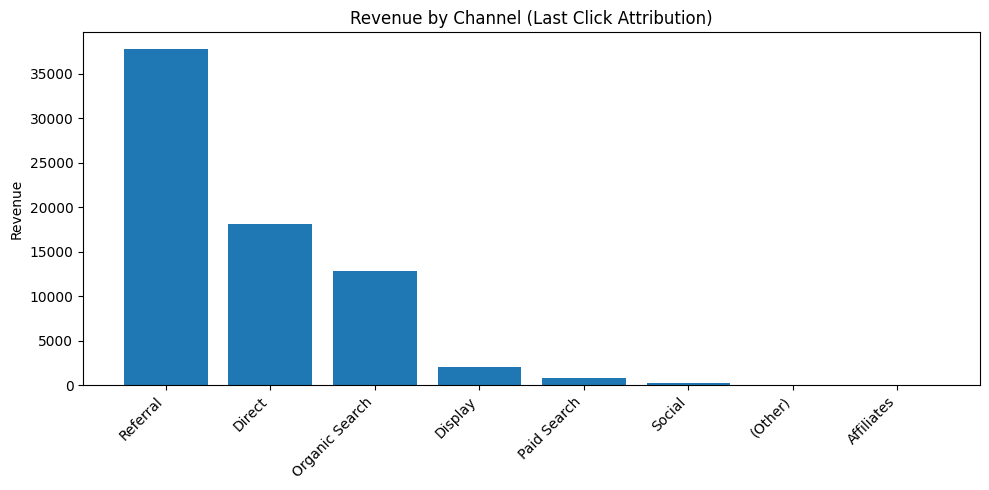

In [8]:
from src.data_loader import load_data
from src.attribution import last_click_attribution
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD PREPROCESSED DATA
# ----------------------------
df = load_data("data/processed/clean.parquet")

print("Shape:", df.shape)
print(df.head())

# ----------------------------
# 2. BASIC EDA
# ----------------------------
print("\nData Summary:")
print(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

# ----------------------------
# 3. ATTRIBUTION MODEL
# ----------------------------
attribution = last_click_attribution(df)

print("\nAttribution sample:")
print(attribution.head())

# ----------------------------
# 4. PLOT ATTRIBUTION
# ----------------------------
def plot_attribution(attribution):

    # Ensure aggregation (safe even if already aggregated)
    df_plot = attribution.copy()

    if 'channelGrouping' in df_plot.columns and 'revenue' in df_plot.columns:
        df_plot = df_plot.groupby('channelGrouping', as_index=False)['revenue'].sum()

    # Sort for clarity
    df_plot = df_plot.sort_values('revenue', ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(df_plot['channelGrouping'], df_plot['revenue'])

    plt.xticks(rotation=45, ha='right')
    plt.title("Revenue by Channel (Last Click Attribution)")
    plt.ylabel("Revenue")

    plt.tight_layout()
    plt.show()

# Call plot
plot_attribution(attribution)

In [9]:
df['revenue'].describe()

count    50000.000000
mean         1.665590
std         36.330169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5498.000000
Name: revenue, dtype: float64

In [12]:
df['totals.transactionRevenue'].value_counts().head()

totals.transactionRevenue
0.0           49349
33590000.0       22
18990000.0       13
13590000.0       12
16990000.0       11
Name: count, dtype: int64

<Axes: xlabel='channelGrouping'>

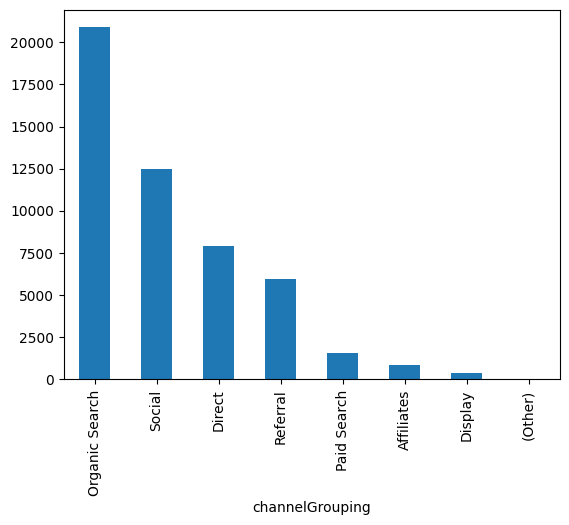

In [13]:
df['channelGrouping'].value_counts().plot(kind='bar')

<Axes: xlabel='channelGrouping'>

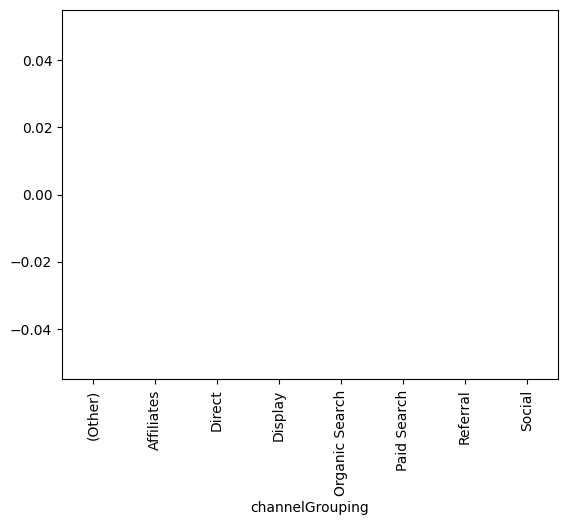

In [14]:
df.groupby('channelGrouping')['totals.transactions'].sum().plot(kind='bar')

In [15]:
df.groupby('fullVisitorId')['totals.transactions'].sum().sort_values(ascending=False).head(10)

fullVisitorId
0000174067426171406    0
0000245437374675368    0
0000750929315523353    0
0001156383977201253    0
0001213046045394417    0
0001285462512259769    0
0001331947010319592    0
0001527863526384268    0
000170187170673177     0
0001960337656851524    0
Name: totals.transactions, dtype: int64